# Spatial ATAC single clustering — P22 mouse brain

This is notebook 1 of 2 in the spatial ATAC-to-ST workflow. It starts from a
P22 mouse-brain spatial ATAC **gene-activity matrix**, runs single-sample
BANKSY, and saves a clustered AnnData object for the alignment notebook.

The paper example contains 9,215 spatial observations measured at 20-µm
resolution. ATAC is clustered independently from the ST reference: matched
genes or a joint ATAC/ST latent space are not required.

## Installation, data, and input contract

Install the package from the repository root:

```bash
cd /path/to/spAlignDE
python -m pip install -e ".[clustering,atlas,tutorial]"
```

The P22 spatial ATAC–RNA dataset is available through the
[UCSC Cell Browser](https://brain-spatial-omics.cells.ucsc.edu/) and
[GEO GSE205055](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE205055).
The original study and processing description are provided in the
[Nature article](https://www.nature.com/articles/s41586-023-05795-1).

spAlignDE accepts either of the following forms:

| Input | Required content |
|---|---|
| AnnData/H5AD | `X`: observations × genes, containing non-negative gene-activity values; `obsm["spatial"]`: finite `(n_obs, 2)` x/y coordinates; unique observation names. |
| Paired CSV | metadata CSV: `cell_id,x,y`; expression CSV: the same `cell_id` values followed by numeric, non-negative gene-activity columns. |

Use an ATAC-derived **gene-activity** matrix, not a peak-by-observation matrix.
Gene activity gives BANKSY a gene-level representation while the alignment
itself uses only independently inferred spatial structures. An R/Seurat RDS
can be used upstream, but it must first be exported to H5AD or the paired CSV
contract above.

Place `p22_atac_gene_activity.h5ad` under
`data/cross_modality/atac/`, or set `SPALIGNDE_ATAC_INPUT` to its path.
For CSV input, set both `SPALIGNDE_ATAC_METADATA_CSV` and
`SPALIGNDE_ATAC_EXPRESSION_CSV`.

In [1]:
%matplotlib inline

from pathlib import Path
import os
import time
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from IPython.utils.capture import capture_output

import spAlignDE

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "src").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from the spAlignDE repository.")


PROJECT_ROOT = find_project_root(Path.cwd())
OUTPUT_DIR = PROJECT_ROOT / "tutorials" / "cross_modality" / "atac" / "output"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
default_input = PROJECT_ROOT / "data" / "cross_modality" / "atac" / "p22_atac_gene_activity.h5ad"
atac_h5ad = Path(os.environ.get("SPALIGNDE_ATAC_INPUT", default_input)).expanduser()
metadata_csv = os.environ.get("SPALIGNDE_ATAC_METADATA_CSV")
expression_csv = os.environ.get("SPALIGNDE_ATAC_EXPRESSION_CSV")

if metadata_csv or expression_csv:
    if not (metadata_csv and expression_csv):
        raise ValueError("Set both ATAC CSV environment variables.")
    atac = spAlignDE.load_single_sample_data(
        Path(metadata_csv).expanduser(),
        expression_csv=Path(expression_csv).expanduser(),
    )
    input_mode = "paired CSV"
else:
    atac = spAlignDE.load_single_sample_data(atac_h5ad)
    input_mode = "AnnData/H5AD"

print(f"Input mode: {input_mode}")
print(f"ATAC input: {atac.n_obs:,} observations × {atac.n_vars:,} gene-activity features")
print("Spatial array:", atac.obsm["spatial"].shape)

Input mode: AnnData/H5AD
ATAC input: 9,215 observations × 24,027 gene-activity features
Spatial array: (9215, 2)


## Run single-sample BANKSY

The paper workflow uses 30 spatial neighbors, scaled-Gaussian neighbor
weighting, `λ = 0.6`, 20 principal components, and Leiden resolution 1.0.
The random seed is fixed. Optional boundary-aware refinement is retained as a
QC label layer; the paper ATAC-to-ST structure matching below uses the raw
BANKSY partition (`cluster_raw`) so it is not altered by a second local voting
step.

Dependency versions can cause small changes at cluster boundaries and may
renumber categorical labels. Reproduction should therefore be judged by the
spatial partition and final geometry rather than integer label identity.

In [3]:
cluster_config = spAlignDE.SingleClusteringConfig(
    num_neighbors=30,
    banksy_lambda=0.6,
    resolution=1.0,
    pca_dim=20,
    max_m=1,
    decay="scaled_gaussian",
    random_state=1234,
    refine_boundaries=True,
)

started = time.perf_counter()
with capture_output() as banksy_capture:
    clustered, details = spAlignDE.cluster_single(
        atac,
        config=cluster_config,
        banksy_output_dir=OUTPUT_DIR / "banksy_diagnostics",
        return_details=True,
    )
plt.close("all")
elapsed = time.perf_counter() - started

summary = pd.DataFrame(
    {
        "value": [
            f"{clustered.n_obs:,}",
            f"{clustered.n_vars:,}",
            clustered.obs["cluster_raw"].nunique(),
            clustered.obs["cluster_refined"].nunique(),
            f"{elapsed / 60:.2f} min",
        ]
    },
    index=["observations", "features", "raw clusters", "refined clusters", "runtime"],
)
display(summary)

,value
observations,"9,215"
features,"24,027"
raw clusters,17
refined clusters,17
runtime,2.02 min


### How to adapt the clustering parameters

Tune clustering before changing alignment parameters. Keep the random seed and
all other settings fixed while comparing a small grid of candidate values.

- `num_neighbors`: increasing it summarizes a broader spatial neighborhood and
  usually smooths structures; reduce it if thin domains disappear.
- `banksy_lambda`: increasing it gives spatial-neighborhood information more
  influence relative to each observation's own expression.
- `resolution`: increasing it usually produces more Leiden clusters. Reject
  settings that create many tiny sample-specific fragments or merge clearly
  distinct spatial domains.
- `snn_neighbors` and `harmony_theta` (joint clustering only): the former
  broadens graph connectivity and the latter strengthens sample correction.
  Do not erase biological differences merely to maximize shared labels.
- `refine_boundaries`: compare `cluster_raw` and `cluster_refined` spatially.
  Refinement should remove isolated boundary noise without erasing narrow
  structures.

Select a configuration using spatial coherence, boundary preservation, cluster
size and coverage in every required sample. Cluster integer values are
arbitrary and may be renumbered across runs; compare memberships and maps, not
label numbers. The website **Parameter Tuning Guide** gives the complete
clustering-to-alignment tuning order.

## Inspect the spatial partition and boundary refinement

The two panels use the same color mapping. The raw labels define the structure
channels in notebook 2; refined labels remain available for checking whether
local voting changes narrow or boundary-adjacent regions too aggressively.

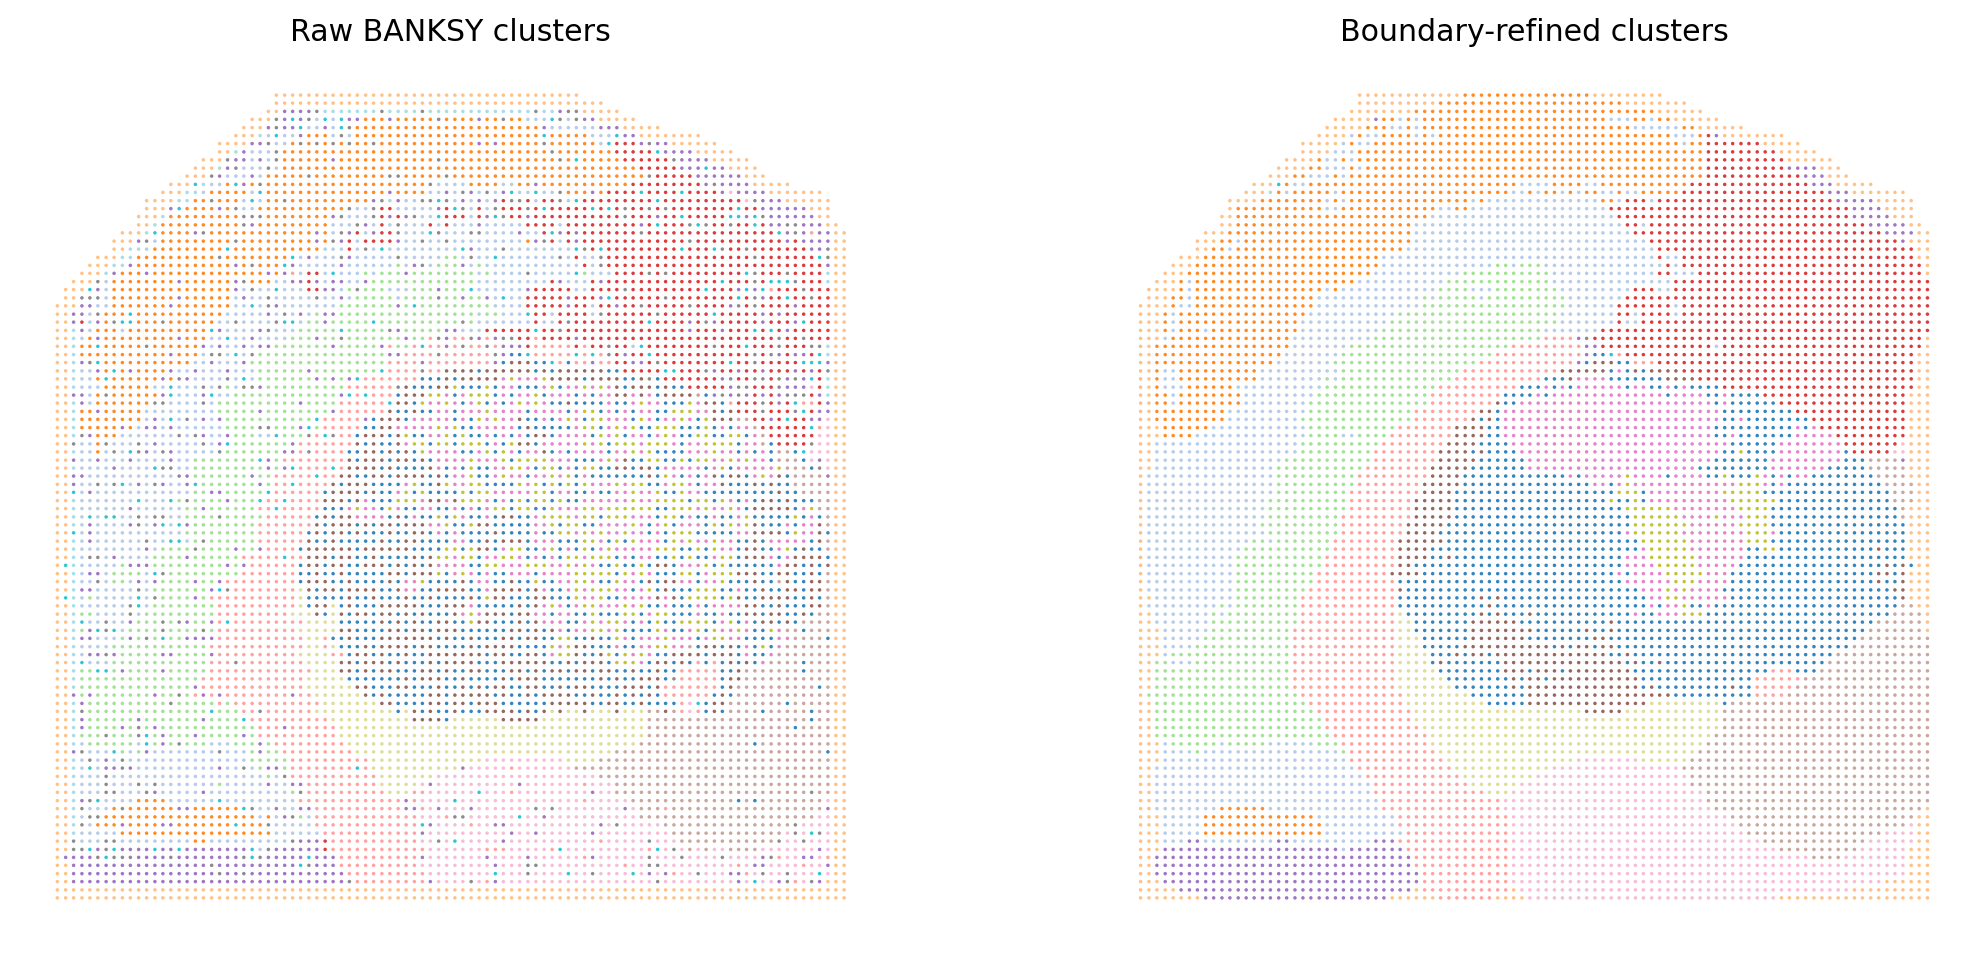

In [4]:
fig, axes = spAlignDE.plot_single_cluster_refinement(
    clustered,
    point_size=2.0,
    palette="tab20",
    alpha=0.90,
    figsize=(12, 5.2),
)
fig.savefig(FIGURE_DIR / "atac_clusters_raw_vs_refined.png", dpi=220, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "atac_clusters_raw_vs_refined.svg", bbox_inches="tight")
plt.show()

## Save the explicit handoff to notebook 2

The output keeps the original gene-activity matrix and
`obsm["spatial"]`, and adds:

- `obs["cluster_raw"]`: the selected BANKSY partition used for ATAC-to-ST;
- `obs["cluster_refined"]`: boundary-aware QC labels; and
- `obs["cluster"]`: the package-selected canonical labels.

Parameters and provenance are stored under `adata.uns["spAlignDE"]`.

In [5]:
clustered_path = OUTPUT_DIR / "p22_atac_single_clustered.h5ad"
clustered.write_h5ad(clustered_path)

cluster_table = clustered.obs[["cluster_raw", "cluster_refined", "cluster"]].copy()
cluster_table.insert(0, "cell_id", clustered.obs_names.astype(str))
cluster_table[["x", "y"]] = clustered.obsm["spatial"]
cluster_table.to_csv(OUTPUT_DIR / "p22_atac_cluster_labels.csv", index=False)

print("Saved clustered AnnData:", clustered_path.relative_to(PROJECT_ROOT))
print("Next notebook cluster key: cluster_raw")
display(cluster_table.head())

Saved clustered AnnData: tutorials/cross_modality/atac/output/p22_atac_single_clustered.h5ad
Next notebook cluster key: cluster_raw


,cell_id,cluster_raw,cluster_refined,cluster,x,y
observation_id,,,,,,
CTAAGGTCTTGCTGGA,CTAAGGTCTTGCTGGA,3,7,7,217.0,2326.0
CTAAGGTCACACAGAA,CTAAGGTCACACAGAA,3,3,3,217.0,404.0
CTAAGGTCACAGCAGA,CTAAGGTCACAGCAGA,3,3,3,217.0,428.0
CTAAGGTCACCTCCAA,CTAAGGTCACCTCCAA,3,3,3,217.0,451.0
CTAAGGTCACGCTCGA,CTAAGGTCACGCTCGA,16,2,2,217.0,475.0
